<h1 style="text-align:center;">Customer Churn Prediction Report</h1>

## 1 Problem Definition

This project aims to develop predictive machine-learning models to identify customers at risk of churn. The target variable in this dataset is **Churned**, which indicates whether a customer has left or is at risk of leaving the business.

Customer churn prediction is an important business problem because retaining existing customers is often more cost-effective than acquiring new ones. By identifying high-risk customers early, a business can design targeted retention strategies such as personalized promotions, improved service, or loyalty programs.

This is a **classification problem**, since the objective is to predict a binary outcome: churned or not churned. The dataset includes customer demographic information, purchase history, engagement behaviour, app usage, and account value, which together may help explain customer churn patterns.

## 2 Exploratory Data Analysis

This section explores the key features used in the final model and examines how they relate to customer churn. The goal is to visually identify patterns between the selected predictors and the target variable **Churned**.

The final best model uses the following 20 features.

*Table 1. Features used in the final best model*

<table style="margin-left:0; border-collapse:collapse;">
<tr>
<th style="text-align:left; width:180px;">Model Name</th>
<th style="text-align:left;">Features</th>
</tr>

<tr>
<td style="vertical-align:top;">
Voting Classifier
</td>

<td>
<ul style="margin-top:0;">
<li>Age</li>
<li>Membership_Years</li>
<li>Login_Frequency</li>
<li>Session_Duration_Avg</li>
<li>Pages_Per_Session</li>
<li>Cart_Abandonment_Rate</li>
<li>Wishlist_Items</li>
<li>Total_Purchases</li>
<li>Average_Order_Value</li>
<li>Days_Since_Last_Purchase</li>
<li>Discount_Usage_Rate</li>
<li>Returns_Rate</li>
<li>Email_Open_Rate</li>
<li>Customer_Service_Calls</li>
<li>Product_Reviews_Written</li>
<li>Social_Media_Engagement_Score</li>
<li>Mobile_App_Usage</li>
<li>Payment_Method_Diversity</li>
<li>Lifetime_Value</li>
<li>Credit_Balance</li>
</ul>
</td>

</tr>
</table>

*Figure 1. Distribution of the best model features.*

![Feature Histograms](figures/figure1_feature_histograms.png)

The feature distributions reveal several behavioural patterns:

- **Engagement features** such as *Login Frequency* and *Pages Per Session* are concentrated around moderate values, suggesting consistent platform usage.
- **Purchase behaviour features** such as *Total Purchases* is right-skewed, indicating that a small number of customers contribute to higher spending.
- **Recency behaviour** such as *Days Since Last Purchase*, shows a long tail, which may reflect customers becoming inactive over time.
- **Categorical variables** (*Country*, *City*, *Signup Quarter*) appear as binary distributions due to one-hot encoding.

*Figure 2. Relationship between selected features and target.*

![Feature Target](figures/figure2_features_vs_churn.png)

The relationship between selected features and the churn target reveals several behavioural patterns:

- **Shopping behaviour**, such as *Cart Abandonment Rate*, tends to be higher among churned customers, suggesting that customers who frequently abandon their carts may be less committed to completing purchases.
- **Price sensitivity behaviour**, represented by *Discount Usage Rate*, shows that churned customers appear to rely more heavily on discounts, which may indicate lower loyalty or stronger sensitivity to pricing.
- **Customer support interaction**, such as *Customer Service Calls*, appears higher among churned customers, which may reflect dissatisfaction or unresolved issues prior to churn.

*Figure 3. Correlation between selected features and churn.*

<img src="figures/figure3_correlation_heatmap.png" width="500">

The correlation heatmap shows how each selected feature is linearly related to the churn target.

- **Customer Service Calls** and **Cart Abandonment Rate** show the strongest positive correlation with churn. Customers who contact support more often or frequently abandon their shopping carts are more likely to churn. This may indicate dissatisfaction or hesitation during the purchasing process.
- **Pages Per Session** and **Email Open Rate** show the strongest negative correlation with churn. Customers who browse more pages or open emails more often tend to stay active on the platform, which may reduce the likelihood of churn.
- Few features such as **Country** and **City** have correlations close to 0.00. This means they do not show a strong linear relationship with churn individually. However, they may still help the model when combined with other features.

*Figure 4. ROC curve of the final voting classifier model.*

<img src="figures/figure4_roc_curve.png" width="500">

The ROC curve shows the classification performance of the final voting model. The curve stays well above the diagonal baseline, indicating that the model can clearly distinguish between churned and non-churned customers. The model achieves an **AUC score of 0.926**, which indicates strong predictive performance and good ability to identify customers at risk of churn.

## 4 Model Evaluation

This section evaluates the predictive models developed for the churn prediction task. Multiple models were tested and compared to identify the best performing approach. Model performance was evaluated using cross validation and an unseen test dataset to ensure that the results are reliable and generalizable.

### 4.1 Feature Selection

Two automated feature selection methods were applied: **Chi-square filtering** and **Recursive Feature Elimination (RFE)**.
Several feature combinations were tested:
- Chi-square only  
- RFE only  
- Intersection of Chi-square and RFE  
- Union of Chi-square and RFE  
- Chi-square followed by RFE
  
Each feature set was evaluated using cross-validation and unseen test data. The RFE produced the best overall performance, with a test AUC of approximately 0.791.
Therefore, the RFE feature set was selected for building the final models.

### 4.2 Model Selection

Multiple machine learning models were built to evaluate different modelling strategies. The following models were implemented:

- Logistic Regression as a baseline statistical model
- Random Forest as a tree-based ensemble model
- Bagging with Decision Trees to improve model stability
- A Voting Classifier combining Logistic Regression, Random Forest, and Gradient Boosting
- A manual Stacking model combining Logistic Regression, Decision Tree, AdaBoost, and Random Forest, following the method demonstrated in Lab Week 3

### 4.3 Hyperparameter Tuning

Hyperparameter tuning was performed using Randomized Search. The search process tested several parameter settings for each model to identify configurations that improve predictive performance. Cross validation was used during the tuning process to reduce the risk of overfitting and to ensure stable model performance.

*Table 2. Hyperparameter tuning results using Randomized Search and cross-validation.*
| Model | Best Parameters | Best CV AUC |
|------|----------------|------------|
| DecisionTree | max_depth=7 | 0.8973785414202912 |
| Bagging (DecisionTree) | n_estimators=150, max_samples=0.8, max_features=0.8 | 0.9166685220874153 |
| RandomForest | n_estimators=100, min_samples_split=5, max_depth=10 | 0.9200697516534536 |
| GradientBoosting | n_estimators=100, max_depth=3, learning_rate=0.1 | 0.9244279372831287 |

### 4.4 Model Comparison

Model performance was evaluated using cross validation and an unseen test dataset. Several evaluation metrics were used to provide a comprehensive comparison, including AUC, Accuracy, F1-score, Precision, and Recall. The final voting classifier achieved the strongest overall performance and is therefore selected as the best model.

*Table 3. Comparison of model performance using cross-validation and unseen test data.*

| Model Type | Features | Data Treatment | CV_AUC_Mean | CV_AUC_Std | CV_Acc_Mean | CV_Acc_Std | CV_F1_Mean | CV_F1_Std | CV_Precision_Mean | CV_Precision_Std | CV_Recall_Mean | CV_Recall_Std | Unseen_Test_AUC | Unseen_Test_Acc | Unseen_Test_F1 |
|------|------|------|-------------|------------|-------------|------------|------------|-----------|------------------|-----------------|---------------|---------------|----------------|---------------|---------------|
| **Voting(LR+RF+GB)** ⭐ | 20 RFE-selected features | One-hot encoding, scaling applied for LR input | 0.922732 | 0.003374 | 0.914625 | 0.002140 | 0.836807 | 0.004327 | 0.934770 | 0.003763 | 0.757439 | 0.005293 | **0.926477** | **0.9145** | **0.836364** |
| RandomForest | 20 RFE-selected features | One-hot encoding, no scaling required | 0.920070 | 0.003929 | 0.909175 | 0.003048 | 0.827021 | 0.005889 | 0.919740 | 0.006652 | 0.751298 | 0.006153 | 0.924211 | 0.9117 | 0.832161 |
| Bagging(DecisionTree) | 20 RFE-selected features | One-hot encoding, no scaling required | 0.916669 | 0.004157 | 0.903500 | 0.002845 | 0.814427 | 0.005881 | 0.916582 | 0.005352 | 0.732785 | 0.007428 | 0.918920 | 0.9058 | 0.819194 |
| Manual Stacking(LR+DT+Ada+RF → LR) | 20 RFE-selected features | One-hot encoding, scaling used for LR meta model | 0.896083 | 0.004880 | 0.909400 | 0.004531 | 0.829586 | 0.008157 | 0.908975 | 0.011496 | 0.762976 | 0.006605 | 0.898099 | 0.9103 | 0.831359 |
| LogisticRegression | 20 RFE-selected features | One-hot encoding + StandardScaler | 0.788227 | 0.007679 | 0.779075 | 0.005488 | 0.523365 | 0.013368 | 0.695093 | 0.016558 | 0.419810 | 0.013434 | 0.790880 | 0.7742 | 0.518960 |

The voting classifier achieved the best overall performance across both cross-validation and unseen test data. 
It produced the highest AUC, accuracy, and F1 score among all evaluated models. Therefore, the voting classifier is selected as the final best model for customer churn prediction.

## 5 Conclusion

This project developed machine learning models to predict customer churn using behavioural, purchasing, and engagement features. Multiple models were evaluated, including Logistic Regression, Random Forest, Bagging, Stacking, and a Voting classifier. 
The **Voting classifier** achieved the best overall performance with a **test AUC of 0.926**, showing strong ability to distinguish between churned and non-churned customers. 
These results suggest that combining multiple models can improve predictive performance and help businesses identify customers at risk of churn more effectively.

## 6 Code Appendix

This section contains the complete code used for data preprocessing, feature selection, model development, hyperparameter tuning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from mlxtend.classifier import EnsembleVoteClassifier

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    return df

In [3]:
def split_features_target(df, target_col="Churned"):
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    return X, y

In [4]:
def data_preprocessing(X):
    X = X.copy()
    # numeric
    num_cols = X.select_dtypes(include=['float64', 'int64']).columns
    X[num_cols] = X[num_cols].fillna(X[num_cols].median())

    # object
    cat_cols = X.select_dtypes(include=['object']).columns
    X[cat_cols] = X[cat_cols].fillna('Unknown')

    X = pd.get_dummies(X, drop_first=True)

    # convert bool columns to int (0/1)
    bool_cols = X.select_dtypes(include=['bool']).columns
    X[bool_cols] = X[bool_cols].astype(int)
    
    return X

In [5]:
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    return X_train, X_test, y_train, y_test

In [6]:

df = load_data("ecommerce_customer_churn_dataset.csv")
X, y = split_features_target(df)
X = data_preprocessing(X)
X_train, X_test, y_train, y_test = split_data(X, y)

print("Data preparation complete.")

Data preparation complete.


In [7]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
# # ---------
# # feature selection method one: chi2 > 3.8
# # ---------
chi2_threshold = 3.8  

#  MinMax can make the data range [0,1]
scaler_chi = MinMaxScaler()
X_train_chi = pd.DataFrame(scaler_chi.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_chi  = pd.DataFrame(scaler_chi.transform(X_test), columns=X_test.columns, index=X_test.index)

chi2_scores, chi2_p = chi2(X_train_chi, y_train)

chi2_df = pd.DataFrame({
    "feature": X_train.columns,
    "chi2": chi2_scores,
    "p_value": chi2_p
}).sort_values("chi2", ascending=False)

chi2_selected = chi2_df.loc[chi2_df["chi2"] > chi2_threshold, "feature"].tolist()

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
# # ---------
# # feature selection method two: rfe select 20 features
# # ---------
rfe_k = 20
scaler_rfe = StandardScaler()

X_train_rfe = scaler_rfe.fit_transform(X_train)
X_test_rfe  = scaler_rfe.transform(X_test)

lr = LogisticRegression(max_iter=2000, solver="liblinear", random_state=42)

rfe = RFE(estimator=lr, n_features_to_select=rfe_k)
rfe.fit(X_train_rfe, y_train)

rfe_selected = X_train.columns[rfe.get_support()].tolist()

In [9]:
# # ---------
# # feature selection method mixed
# # ---------
chi2_set = set(chi2_selected)
rfe_set  = set(rfe_selected)

features_chi2_only = sorted(list(chi2_set))
features_rfe_only  = sorted(list(rfe_set))
features_intersection = sorted(list(chi2_set & rfe_set))
features_union = sorted(list(chi2_set | rfe_set))

In [10]:
# ---------
# feature selection method four: Chi2 -> RFE
# ---------

X_train_chi = X_train[features_chi2_only]

scaler_chi_rfe = StandardScaler()
X_train_chi_scaled = scaler_chi_rfe.fit_transform(X_train_chi)

rfe_k2 = 15

rfe2 = RFE(estimator=lr, n_features_to_select=rfe_k2)
rfe2.fit(X_train_chi_scaled, y_train)

chi2_rfe_features = X_train_chi.columns[rfe2.get_support()].tolist()

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_feature_set(feature_list, set_name):

    Xtr = X_train[feature_list]
    Xte = X_test[feature_list]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(Xtr)
    X_test_s = scaler.transform(Xte)

    model = LogisticRegression(max_iter=2000, solver="liblinear", random_state=42)

    cv_auc = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="roc_auc")
    cv_f1  = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="f1")
    cv_acc = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="accuracy")
    cv_prec = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="precision")
    cv_rec  = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="recall")

    model.fit(X_train_s, y_train)

    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]

    test_auc = roc_auc_score(y_test, proba)
    test_f1  = f1_score(y_test, pred)
    test_acc = accuracy_score(y_test, pred)

    return {
        "Feature_Set": set_name,
        "Num_Features": len(feature_list),
        "CV_AUC_Mean": cv_auc.mean(), "CV_AUC_Std": cv_auc.std(),
        "CV_F1_Mean":  cv_f1.mean(),  "CV_F1_Std":  cv_f1.std(),
        "CV_Acc_Mean": cv_acc.mean(), "CV_Acc_Std": cv_acc.std(),
        "CV_Precision_Mean": cv_prec.mean(), "CV_Precision_Std": cv_prec.std(),
        "CV_Recall_Mean":  cv_rec.mean(),  "CV_Recall_Std":  cv_rec.std(),
        "Unseen_Test_AUC": test_auc,
        "Unseen_Test_F1":  test_f1,
        "Unseen_Test_Acc": test_acc
    }

feature_sets = [
    ("Chi2_only", features_chi2_only),
    ("RFE_only", features_rfe_only),
    ("Intersection", features_intersection),
    ("Union", features_union),
    ("Chi2_RFE", chi2_rfe_features)
]

rows = []
for name, feats in feature_sets:
    if len(feats) < 8:
        print(f"Skip {name}: only {len(feats)} features (<8)")
        continue
    rows.append(evaluate_feature_set(feats, name))

fs_results = pd.DataFrame(rows).sort_values("Unseen_Test_AUC", ascending=False).reset_index(drop=True)
fs_results

,Feature_Set,Num_Features,CV_AUC_Mean,CV_AUC_Std,CV_F1_Mean,CV_F1_Std,CV_Acc_Mean,CV_Acc_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,Unseen_Test_AUC,Unseen_Test_F1,Unseen_Test_Acc
0,RFE_only,20,0.788233,0.007671,0.523232,0.013477,0.779000,0.005572,0.694844,0.016746,0.419723,0.013403,0.790880,0.518960,0.7742
1,Union,26,0.788250,0.007526,0.524997,0.012592,0.779600,0.005343,0.696117,0.016763,0.421540,0.012636,0.790604,0.519198,0.7746
2,Intersection,13,0.751837,0.008335,0.452024,0.009410,0.761875,0.003846,0.674876,0.014464,0.339879,0.008429,0.757386,0.474007,0.7683
3,Chi2_RFE,15,0.752041,0.007958,0.450934,0.010619,0.761450,0.004145,0.673537,0.015678,0.339014,0.009853,0.756945,0.471659,0.7679
4,Chi2_only,19,0.751844,0.008000,0.451379,0.011529,0.761525,0.004337,0.673491,0.015872,0.339533,0.010728,0.756892,0.470963,0.7677


In [12]:
# final features for all models (hard coded)
selected_features = [
    "Age",
    "Login_Frequency",
    "Pages_Per_Session",
    "Cart_Abandonment_Rate",
    "Wishlist_Items",
    "Total_Purchases",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Returns_Rate",
    "Email_Open_Rate",
    "Customer_Service_Calls",
    "Product_Reviews_Written",
    "Mobile_App_Usage",
    "Lifetime_Value",
    "Country_Canada",
    "Country_USA",
    "City_Leeds",
    "City_Marseille",
    "City_Melbourne",
    "Signup_Quarter_Q4"
]

X_train_sel = X_train[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

In [13]:
# =========================
# 3.0 Hyperparameter Tuning
# Lightweight RandomizedSearchCV
# =========================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

tuning_results = []
random_state = 42
# -----------------------------------
# (A) DecisionTree tuning
# only tune max_depth
# -----------------------------------
dt_param_dist = {
    "max_depth": [3, 5, 7, 10]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_distributions=dt_param_dist,
    n_iter=4,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=random_state
)

dt_search.fit(X_train_sel, y_train)

best_dt_params = dt_search.best_params_
best_dt_score = dt_search.best_score_

tuning_results.append({
    "Model": "DecisionTree",
    "Best_Params": best_dt_params,
    "Best_CV_AUC": best_dt_score
})

print("Best DecisionTree params:", best_dt_params)
print("Best DecisionTree CV AUC:", best_dt_score)


# -----------------------------------
# (B) Bagging(DecisionTree) tuning
# -----------------------------------
best_dt_for_bag = DecisionTreeClassifier(
    **best_dt_params,
    random_state=random_state
)

bag_param_dist = {
    "n_estimators": [50, 100, 150],
    "max_samples": [0.7, 0.8, 1.0],
    "max_features": [0.8, 1.0],
    "bootstrap": [True]
}

bag_search = RandomizedSearchCV(
    estimator=BaggingClassifier(
        estimator=best_dt_for_bag,
        random_state=random_state,
        n_jobs=-1
    ),
    param_distributions=bag_param_dist,
    n_iter=4,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=random_state
)

bag_search.fit(X_train_sel, y_train)

best_bag_params = bag_search.best_params_
best_bag_score = bag_search.best_score_

tuning_results.append({
    "Model": "Bagging(DecisionTree)",
    "Best_Params": best_bag_params,
    "Best_CV_AUC": best_bag_score
})

print("\nBest Bagging params:", best_bag_params)
print("Best Bagging CV AUC:", best_bag_score)


# -----------------------------------
# (C) RandomForest tuning
# -----------------------------------
rf_param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [5, 8, 10],
    "min_samples_split": [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=random_state,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=4,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=random_state
)

rf_search.fit(X_train_sel, y_train)

best_rf_params = rf_search.best_params_
best_rf_score = rf_search.best_score_

tuning_results.append({
    "Model": "RandomForest",
    "Best_Params": best_rf_params,
    "Best_CV_AUC": best_rf_score
})

print("\nBest RandomForest params:", best_rf_params)
print("Best RandomForest CV AUC:", best_rf_score)


# -----------------------------------
# (D) GradientBoosting tuning
# -----------------------------------
gb_param_dist = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=random_state),
    param_distributions=gb_param_dist,
    n_iter=4,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=random_state
)

gb_search.fit(X_train_sel, y_train)

best_gb_params = gb_search.best_params_
best_gb_score = gb_search.best_score_

tuning_results.append({
    "Model": "GradientBoosting",
    "Best_Params": best_gb_params,
    "Best_CV_AUC": best_gb_score
})

print("\nBest GradientBoosting params:", best_gb_params)
print("Best GradientBoosting CV AUC:", best_gb_score)


# -----------------------------------
# (F) Summary table
# -----------------------------------
tuning_results_df = pd.DataFrame(tuning_results)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_columns", None)
tuning_results_df

# Save tuning results
tuning_results_df.to_csv("tuning_results.csv", index=False)
print("tuning_results.csv saved")

Best DecisionTree params: {'max_depth': 7}
Best DecisionTree CV AUC: 0.8973785414202912

Best Bagging params: {'n_estimators': 150, 'max_samples': 0.8, 'max_features': 0.8, 'bootstrap': True}
Best Bagging CV AUC: 0.9166685220874153

Best RandomForest params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
Best RandomForest CV AUC: 0.9200697516534536

Best GradientBoosting params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best GradientBoosting CV AUC: 0.9244279372831287
tuning_results.csv saved


In [14]:
# =========================
# 3.1 Bagging Section
# Single vs Bagging(Tree)
# Single vs Bagging(KNN)
# CV + Unseen Test Evaluation
# =========================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier


# ---------
# (A) CV config
# ---------
n_splits = 5
random_state = 42

# StratifiedKFold is better for classification model balance
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# ---------
# (B) Helper: scaling (only for models that need it)
# ---------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)


# ---------
# (C) Helper: evaluate on unseen test
# ---------
def evaluate_on_test(model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred)

    # AUC: use predict_proba if available, otherwise decision_function
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        auc = roc_auc_score(y_test, scores)
    else:
        auc = np.nan

    return acc, f1, auc


# ---------
# (D) Define base models
# ---------
dt  = DecisionTreeClassifier(max_depth=7, random_state=random_state)
knn = KNeighborsClassifier()

models = [
    ("DecisionTree", dt, X_train_sel, X_test_sel),
    ("KNN", knn, X_train_scaled, X_test_scaled),
]

# ---------
# (E) Run: Single vs Bagging for each base model
# ---------
results = []

for name, base_model, Xtrain_use, Xtest_use in models:

    # --- 1) Single model CV ---
    scores = cross_validate(
    base_model,
    Xtrain_use,
    y_train,
    cv=cv,
    scoring=["roc_auc","accuracy","f1","precision","recall"]
    )

    cv_auc = scores["test_roc_auc"]
    cv_acc = scores["test_accuracy"]
    cv_f1  = scores["test_f1"]
    cv_prec = scores["test_precision"]
    cv_rec  = scores["test_recall"]

    # fit on full training and evaluate on unseen test
    single_fit = base_model.fit(Xtrain_use, y_train)
    test_acc, test_f1, test_auc = evaluate_on_test(single_fit, Xtest_use, y_test)
    results.append({
        "Model": name,
        "Type": "Single",
        "CV_AUC_Mean": cv_auc.mean(), "CV_AUC_Std": cv_auc.std(),
        "CV_Acc_Mean": cv_acc.mean(), "CV_Acc_Std": cv_acc.std(),
        "CV_F1_Mean":  cv_f1.mean(),  "CV_F1_Std":  cv_f1.std(),
        "CV_Precision_Mean": cv_prec.mean(), "CV_Precision_Std": cv_prec.std(),
        "CV_Recall_Mean":  cv_rec.mean(),  "CV_Recall_Std":  cv_rec.std(),
        "Unseen_Test_AUC": test_auc,
        "Unseen_Test_Acc": test_acc,
        "Unseen_Test_F1":  test_f1,
    })

    # --- 2) Bagging model CV ---
    # use tuned bagging parameters from Bagging(DecisionTree)
    bag_model = BaggingClassifier(
        estimator=base_model,
        n_estimators=150,     
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=random_state,
        n_jobs=-1
    )

    bag_scores = cross_validate(
    bag_model,
    Xtrain_use,
    y_train,
    cv=cv,
    scoring=["roc_auc","accuracy","f1","precision","recall"]
    )

    bag_cv_auc = bag_scores["test_roc_auc"]
    bag_cv_acc = bag_scores["test_accuracy"]
    bag_cv_f1  = bag_scores["test_f1"]
    bag_cv_prec = bag_scores["test_precision"]
    bag_cv_rec  = bag_scores["test_recall"]

    bag_fit = bag_model.fit(Xtrain_use, y_train)
    bag_test_acc, bag_test_f1, bag_test_auc = evaluate_on_test(bag_fit, Xtest_use, y_test)

    results.append({
        "Model": f"Bagging({name})",
        "Type": "Bagging",
        "CV_AUC_Mean": bag_cv_auc.mean(), "CV_AUC_Std": bag_cv_auc.std(),
        "CV_Acc_Mean": bag_cv_acc.mean(), "CV_Acc_Std": bag_cv_acc.std(),
        "CV_F1_Mean":  bag_cv_f1.mean(),  "CV_F1_Std":  bag_cv_f1.std(),
        "CV_Precision_Mean": bag_cv_prec.mean(), "CV_Precision_Std": bag_cv_prec.std(),
        "CV_Recall_Mean":  bag_cv_rec.mean(),  "CV_Recall_Std":  bag_cv_rec.std(),
        "Unseen_Test_AUC": bag_test_auc,
        "Unseen_Test_Acc": bag_test_acc,
        "Unseen_Test_F1":  bag_test_f1,
    })

# ---------
# (F) Results table
# ---------
bagging_results_df = pd.DataFrame(results)

# order by Test_AUC（ can also change to Test_F1）
bagging_results_df = bagging_results_df.sort_values(by="Unseen_Test_AUC", ascending=False).reset_index(drop=True)

bagging_results_df

# Save bagging results
bagging_results_df.to_csv("bagging_results.csv", index=False)
print("bagging_results.csv saved")

bagging_results.csv saved


In [15]:
# =========================
# 3.2 Voting Section
# Three types of models: LogisticRegression, RandomForestClassifier, GradientBoostingClassifier
# Voting classifier of the three models
# CV + Unseen Test Evaluation
# =========================
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# ---------
# (A) Define three different types of models
# ---------
lr = LogisticRegression(max_iter=1000, random_state=random_state) 
rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    max_depth=10,
    random_state=random_state,
    n_jobs=-1
)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=random_state
)

# ---------
# (B) Voting model
# Use soft voting because all three models support predict_proba
# ---------
vote_model = EnsembleVoteClassifier(clfs=[lr, rf, gb],voting='soft')

# ---------
# (C) Cross validation
# LogisticRegression needs scaled data, so use scaled version for voting
# ---------
vote_scores = cross_validate(
    vote_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=["roc_auc", "accuracy", "f1", "precision", "recall"]
)

vote_cv_auc = vote_scores["test_roc_auc"]
vote_cv_acc = vote_scores["test_accuracy"]
vote_cv_f1  = vote_scores["test_f1"]
vote_cv_prec = vote_scores["test_precision"]
vote_cv_rec  = vote_scores["test_recall"]

# ---------
# (D) Fit on full training data and evaluate on unseen test data
# ---------
vote_fit = vote_model.fit(X_train_scaled, y_train)
vote_test_acc, vote_test_f1, vote_test_auc = evaluate_on_test(vote_fit, X_test_scaled, y_test)

# ---------
# (E) Results table
# ---------
voting_results_df = pd.DataFrame([{
    "Model": "Voting(LR+RF+GB)",
    "Type": "Voting",
    "CV_AUC_Mean": vote_cv_auc.mean(),
    "CV_AUC_Std": vote_cv_auc.std(),
    "CV_Acc_Mean": vote_cv_acc.mean(),
    "CV_Acc_Std": vote_cv_acc.std(),
    "CV_F1_Mean": vote_cv_f1.mean(),
    "CV_F1_Std": vote_cv_f1.std(),
    "CV_Precision_Mean": vote_cv_prec.mean(),
    "CV_Precision_Std": vote_cv_prec.std(),
    "CV_Recall_Mean": vote_cv_rec.mean(),
    "CV_Recall_Std": vote_cv_rec.std(),
    "Unseen_Test_AUC": vote_test_auc,
    "Unseen_Test_Acc": vote_test_acc,
    "Unseen_Test_F1": vote_test_f1,
}])

voting_results_df

# Save voting results
voting_results_df.to_csv("voting_results.csv", index=False)
print("voting_results.csv saved")

voting_results.csv saved


In [16]:
# =========================
# 3.3 Stacking Section
# Manual stacking based on Lab Week 3 method
# Base models -> predictions on validation set -> meta model
# CV + Unseen Test Evaluation
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd


# ---------
# (A) Helper functions from lab-style stacking
# ---------
def get_unfit_stacking_models():
    models = []
    models.append(LogisticRegression(max_iter=1000, random_state=random_state))
    models.append(DecisionTreeClassifier(max_depth=7, random_state=random_state))
    models.append(AdaBoostClassifier(algorithm="SAMME", random_state=random_state))
    models.append(
        RandomForestClassifier(
            n_estimators=100,
            min_samples_split=5,
            max_depth=10,
            random_state=random_state,
            n_jobs=-1
        )
    )
    return models


def fit_base_models(X_train_base, y_train_base, X_meta_input, models):
    n_models = len(models)
    n_samples = X_meta_input.shape[0]

    # store each base model prediction as one column
    meta_features = np.zeros((n_samples, n_models))

    for i, model in enumerate(models):
        model.fit(X_train_base, y_train_base)
        preds = model.predict(X_meta_input)
        meta_features[:, i] = preds

    return meta_features, models


def fit_stacked_model(X_meta, y_meta):
    meta_model = LogisticRegression(max_iter=1000, random_state=random_state)
    meta_model.fit(X_meta, y_meta)
    return meta_model


def fit_manual_stacking(X_train_full, y_train_full, random_state=42):
    # split training data into base-train and meta-train
    X_train_base, X_meta, y_train_base, y_meta = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.30,
        stratify=y_train_full,
        random_state=random_state
    )

    base_models = get_unfit_stacking_models()

    # fit base models on base-train, predict on meta set
    meta_features, fitted_base_models = fit_base_models(
        X_train_base, y_train_base, X_meta, base_models
    )

    # fit meta model on base-model predictions
    stacked_model = fit_stacked_model(meta_features, y_meta)

    return fitted_base_models, stacked_model


def predict_manual_stacking(base_models, stacked_model, X_input):
    n_models = len(base_models)
    n_samples = X_input.shape[0]

    meta_features = np.zeros((n_samples, n_models))

    for i, model in enumerate(base_models):
        preds = model.predict(X_input)
        meta_features[:, i] = preds

    final_preds = stacked_model.predict(meta_features)

    # for AUC
    if hasattr(stacked_model, "predict_proba"):
        final_proba = stacked_model.predict_proba(meta_features)[:, 1]
    else:
        final_proba = None

    return final_preds, final_proba


# ---------
# (B) Manual CV for stacking
# Use scaled data because LogisticRegression is included
# ---------
stack_cv_auc = []
stack_cv_acc = []
stack_cv_f1 = []
stack_cv_prec = []
stack_cv_rec = []

for train_idx, valid_idx in cv.split(X_train_scaled, y_train):
    X_fold_train = X_train_scaled[train_idx]
    X_fold_valid = X_train_scaled[valid_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    fold_base_models, fold_stacked_model = fit_manual_stacking(
        X_fold_train, y_fold_train, random_state=random_state
    )

    fold_pred, fold_proba = predict_manual_stacking(
        fold_base_models, fold_stacked_model, X_fold_valid
    )

    fold_acc = accuracy_score(y_fold_valid, fold_pred)
    fold_f1 = f1_score(y_fold_valid, fold_pred)
    fold_prec = precision_score(y_fold_valid, fold_pred)
    fold_rec = recall_score(y_fold_valid, fold_pred)
    fold_auc = roc_auc_score(y_fold_valid, fold_proba)

    stack_cv_acc.append(fold_acc)
    stack_cv_f1.append(fold_f1)
    stack_cv_prec.append(fold_prec)
    stack_cv_rec.append(fold_rec)
    stack_cv_auc.append(fold_auc)


# ---------
# (C) Fit on full training data and evaluate on unseen test data
# ---------
final_base_models, final_stacked_model = fit_manual_stacking(
    X_train_scaled, y_train, random_state=random_state
)

stack_test_pred, stack_test_proba = predict_manual_stacking(
    final_base_models, final_stacked_model, X_test_scaled
)

stack_test_acc = accuracy_score(y_test, stack_test_pred)
stack_test_f1 = f1_score(y_test, stack_test_pred)
stack_test_auc = roc_auc_score(y_test, stack_test_proba)


# ---------
# (D) Results table
# ---------
stacking_results_df = pd.DataFrame([{
    "Model": "Manual Stacking(LR+DT+Ada+RF -> LR)",
    "Type": "Stacking",
    "CV_AUC_Mean": np.mean(stack_cv_auc),
    "CV_AUC_Std": np.std(stack_cv_auc),
    "CV_Acc_Mean": np.mean(stack_cv_acc),
    "CV_Acc_Std": np.std(stack_cv_acc),
    "CV_F1_Mean": np.mean(stack_cv_f1),
    "CV_F1_Std": np.std(stack_cv_f1),
    "CV_Precision_Mean": np.mean(stack_cv_prec),
    "CV_Precision_Std": np.std(stack_cv_prec),
    "CV_Recall_Mean": np.mean(stack_cv_rec),
    "CV_Recall_Std": np.std(stack_cv_rec),
    "Unseen_Test_AUC": stack_test_auc,
    "Unseen_Test_Acc": stack_test_acc,
    "Unseen_Test_F1": stack_test_f1,
}])

stacking_results_df

# Save stacking results
stacking_results_df.to_csv("stacking_results.csv", index=False)
print("stacking_results.csv saved")

stacking_results.csv saved


In [17]:
# =========================
# 3.4 Logistic Regression Section
# CV + Unseen Test Evaluation
# =========================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=random_state
)

lr_scores = cross_validate(
    lr_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=["roc_auc", "accuracy", "f1", "precision", "recall"]
)

lr_cv_auc = lr_scores["test_roc_auc"]
lr_cv_acc = lr_scores["test_accuracy"]
lr_cv_f1  = lr_scores["test_f1"]
lr_cv_prec = lr_scores["test_precision"]
lr_cv_rec  = lr_scores["test_recall"]

lr_fit = lr_model.fit(X_train_scaled, y_train)
lr_test_acc, lr_test_f1, lr_test_auc = evaluate_on_test(lr_fit, X_test_scaled, y_test)

lr_results_df = pd.DataFrame([{
    "Model": "LogisticRegression",
    "Type": "Single",
    "CV_AUC_Mean": lr_cv_auc.mean(),
    "CV_AUC_Std": lr_cv_auc.std(),
    "CV_Acc_Mean": lr_cv_acc.mean(),
    "CV_Acc_Std": lr_cv_acc.std(),
    "CV_F1_Mean": lr_cv_f1.mean(),
    "CV_F1_Std": lr_cv_f1.std(),
    "CV_Precision_Mean": lr_cv_prec.mean(),
    "CV_Precision_Std": lr_cv_prec.std(),
    "CV_Recall_Mean": lr_cv_rec.mean(),
    "CV_Recall_Std": lr_cv_rec.std(),
    "Unseen_Test_AUC": lr_test_auc,
    "Unseen_Test_Acc": lr_test_acc,
    "Unseen_Test_F1": lr_test_f1,
}])

lr_results_df

# Save LogisticRegression results
lr_results_df.to_csv("logistic_regression_results.csv", index=False)
print("logistic_regression_results.csv saved")

logistic_regression_results.csv saved


In [18]:
# =========================
# 3.5 RandomForest Section
# Single model evaluation
# CV + Unseen Test Evaluation
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# ---------
# (A) Define RandomForest model
# ---------
rf_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    max_depth=10,
    random_state=random_state,
    n_jobs=-1
)

# ---------
# (B) Cross validation
# ---------
rf_scores = cross_validate(
    rf_model,
    X_train_sel,
    y_train,
    cv=cv,
    scoring=["roc_auc", "accuracy", "f1", "precision", "recall"],
    n_jobs=-1
)

rf_cv_auc = rf_scores["test_roc_auc"]
rf_cv_acc = rf_scores["test_accuracy"]
rf_cv_f1  = rf_scores["test_f1"]
rf_cv_prec = rf_scores["test_precision"]
rf_cv_rec  = rf_scores["test_recall"]

# ---------
# (C) Fit on full training data
# ---------
rf_fit = rf_model.fit(X_train_sel, y_train)

# prediction
rf_pred = rf_fit.predict(X_test_sel)

# accuracy / f1
rf_test_acc = accuracy_score(y_test, rf_pred)
rf_test_f1  = f1_score(y_test, rf_pred)

# AUC
if hasattr(rf_fit, "predict_proba"):
    rf_proba = rf_fit.predict_proba(X_test_sel)[:, 1]
    rf_test_auc = roc_auc_score(y_test, rf_proba)
else:
    rf_scores_test = rf_fit.decision_function(X_test_sel)
    rf_test_auc = roc_auc_score(y_test, rf_scores_test)

# ---------
# (D) Results table
# ---------
rf_results_df = pd.DataFrame([{
    "Model": "RandomForest",
    "Type": "Single",
    "CV_AUC_Mean": rf_cv_auc.mean(),
    "CV_AUC_Std": rf_cv_auc.std(),
    "CV_Acc_Mean": rf_cv_acc.mean(),
    "CV_Acc_Std": rf_cv_acc.std(),
    "CV_F1_Mean": rf_cv_f1.mean(),
    "CV_F1_Std": rf_cv_f1.std(),
    "CV_Precision_Mean": rf_cv_prec.mean(),
    "CV_Precision_Std": rf_cv_prec.std(),
    "CV_Recall_Mean": rf_cv_rec.mean(),
    "CV_Recall_Std": rf_cv_rec.std(),
    "Unseen_Test_AUC": rf_test_auc,
    "Unseen_Test_Acc": rf_test_acc,
    "Unseen_Test_F1": rf_test_f1,
}])

rf_results_df

# Save RandomForest results
rf_results_df.to_csv("random_forest_results.csv", index=False)
print("random_forest_results.csv saved")

random_forest_results.csv saved


In [19]:
import pandas as pd

# Load tuning results
tuning_results_df = pd.read_csv("tuning_results.csv")
tuning_results_df
# Load bagging results
bagging_results_df = pd.read_csv("bagging_results.csv")
bagging_results_df
# Load voting results
voting_results_df = pd.read_csv("voting_results.csv")
voting_results_df
# Load stacking results
stacking_results_df = pd.read_csv("stacking_results.csv")
stacking_results_df
# Load logistic_regression results
lr_results_df = pd.read_csv("logistic_regression_results.csv")
lr_results_df
# Load random_forest results
rf_results_df = pd.read_csv("random_forest_results.csv")
rf_results_df

,Model,Type,CV_AUC_Mean,CV_AUC_Std,CV_Acc_Mean,CV_Acc_Std,CV_F1_Mean,CV_F1_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,Unseen_Test_AUC,Unseen_Test_Acc,Unseen_Test_F1
0,RandomForest,Single,0.92007,0.003929,0.909175,0.003048,0.827021,0.005889,0.91974,0.006652,0.751298,0.006153,0.924211,0.9117,0.832161


In [20]:
# =========================
# 4. Final Comparison Table
# Best Bagging + Voting + Stacking + Additional Models
# =========================

# (A) Select the best Bagging model
best_bagging_df = bagging_results_df[
    bagging_results_df["Model"] == "Bagging(DecisionTree)"
].copy()

# (B) Combine the three final models
final_results_df = pd.concat(
    [best_bagging_df, voting_results_df, stacking_results_df, lr_results_df, rf_results_df],
    ignore_index=True
)

# (C) sort by Test_AUC for easier comparison
final_results_df = final_results_df.sort_values(
    by="Unseen_Test_AUC", ascending=False
).reset_index(drop=True)

# (D) Reorder columns for cleaner presentation
final_results_df = final_results_df[
    [
        "Model",
        "Type",
        "CV_AUC_Mean", "CV_AUC_Std",
        "CV_Acc_Mean", "CV_Acc_Std",
        "CV_F1_Mean", "CV_F1_Std",
        "CV_Precision_Mean", "CV_Precision_Std",
        "CV_Recall_Mean", "CV_Recall_Std",
        "Unseen_Test_AUC", "Unseen_Test_Acc", "Unseen_Test_F1"
    ]
]

final_results_df

,Model,Type,CV_AUC_Mean,CV_AUC_Std,CV_Acc_Mean,CV_Acc_Std,CV_F1_Mean,CV_F1_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,Unseen_Test_AUC,Unseen_Test_Acc,Unseen_Test_F1
0,Voting(LR+RF+GB),Voting,0.922732,0.003374,0.914625,0.002140,0.836807,0.004327,0.934770,0.003763,0.757439,0.005293,0.926477,0.9145,0.836364
1,RandomForest,Single,0.920070,0.003929,0.909175,0.003048,0.827021,0.005889,0.919740,0.006652,0.751298,0.006153,0.924211,0.9117,0.832161
2,Bagging(DecisionTree),Bagging,0.916669,0.004157,0.903500,0.002845,0.814427,0.005881,0.916582,0.005352,0.732785,0.007428,0.918920,0.9058,0.819194
3,Manual Stacking(LR+DT+Ada+RF -> LR),Stacking,0.896083,0.004880,0.909400,0.004531,0.829586,0.008157,0.908975,0.011496,0.762976,0.006605,0.898099,0.9103,0.831359
4,LogisticRegression,Single,0.788227,0.007679,0.779075,0.005488,0.523365,0.013368,0.695093,0.016558,0.419810,0.013434,0.790880,0.7742,0.518960


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# dataframe for EDA plots
df_eda = X_train_sel.copy()
df_eda["Churned"] = y_train.values

def get_feature_label(col):
    if col == "Churned":
        return "Target (Churned)"
    return col.replace("_", " ")

In [22]:
def plot_histograms(df_eda, feature_list, n_cols=4, bins=25):
    n = len(feature_list)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(8 * n_cols, 5.5 * n_rows))
    plt.suptitle("Histograms - Selected Features", fontsize=36, weight="bold")

    for i, col in enumerate(feature_list, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        sns.histplot(df_eda[col], bins=bins, kde=False, ax=ax)

        ax.set_title(get_feature_label(col), fontsize=26, weight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Count", fontsize=22, weight="bold")
        ax.tick_params(axis="both", labelsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.45, wspace=0.3)
    plt.savefig("figure1_feature_histograms.png", dpi=300, bbox_inches="tight")

    plt.show()

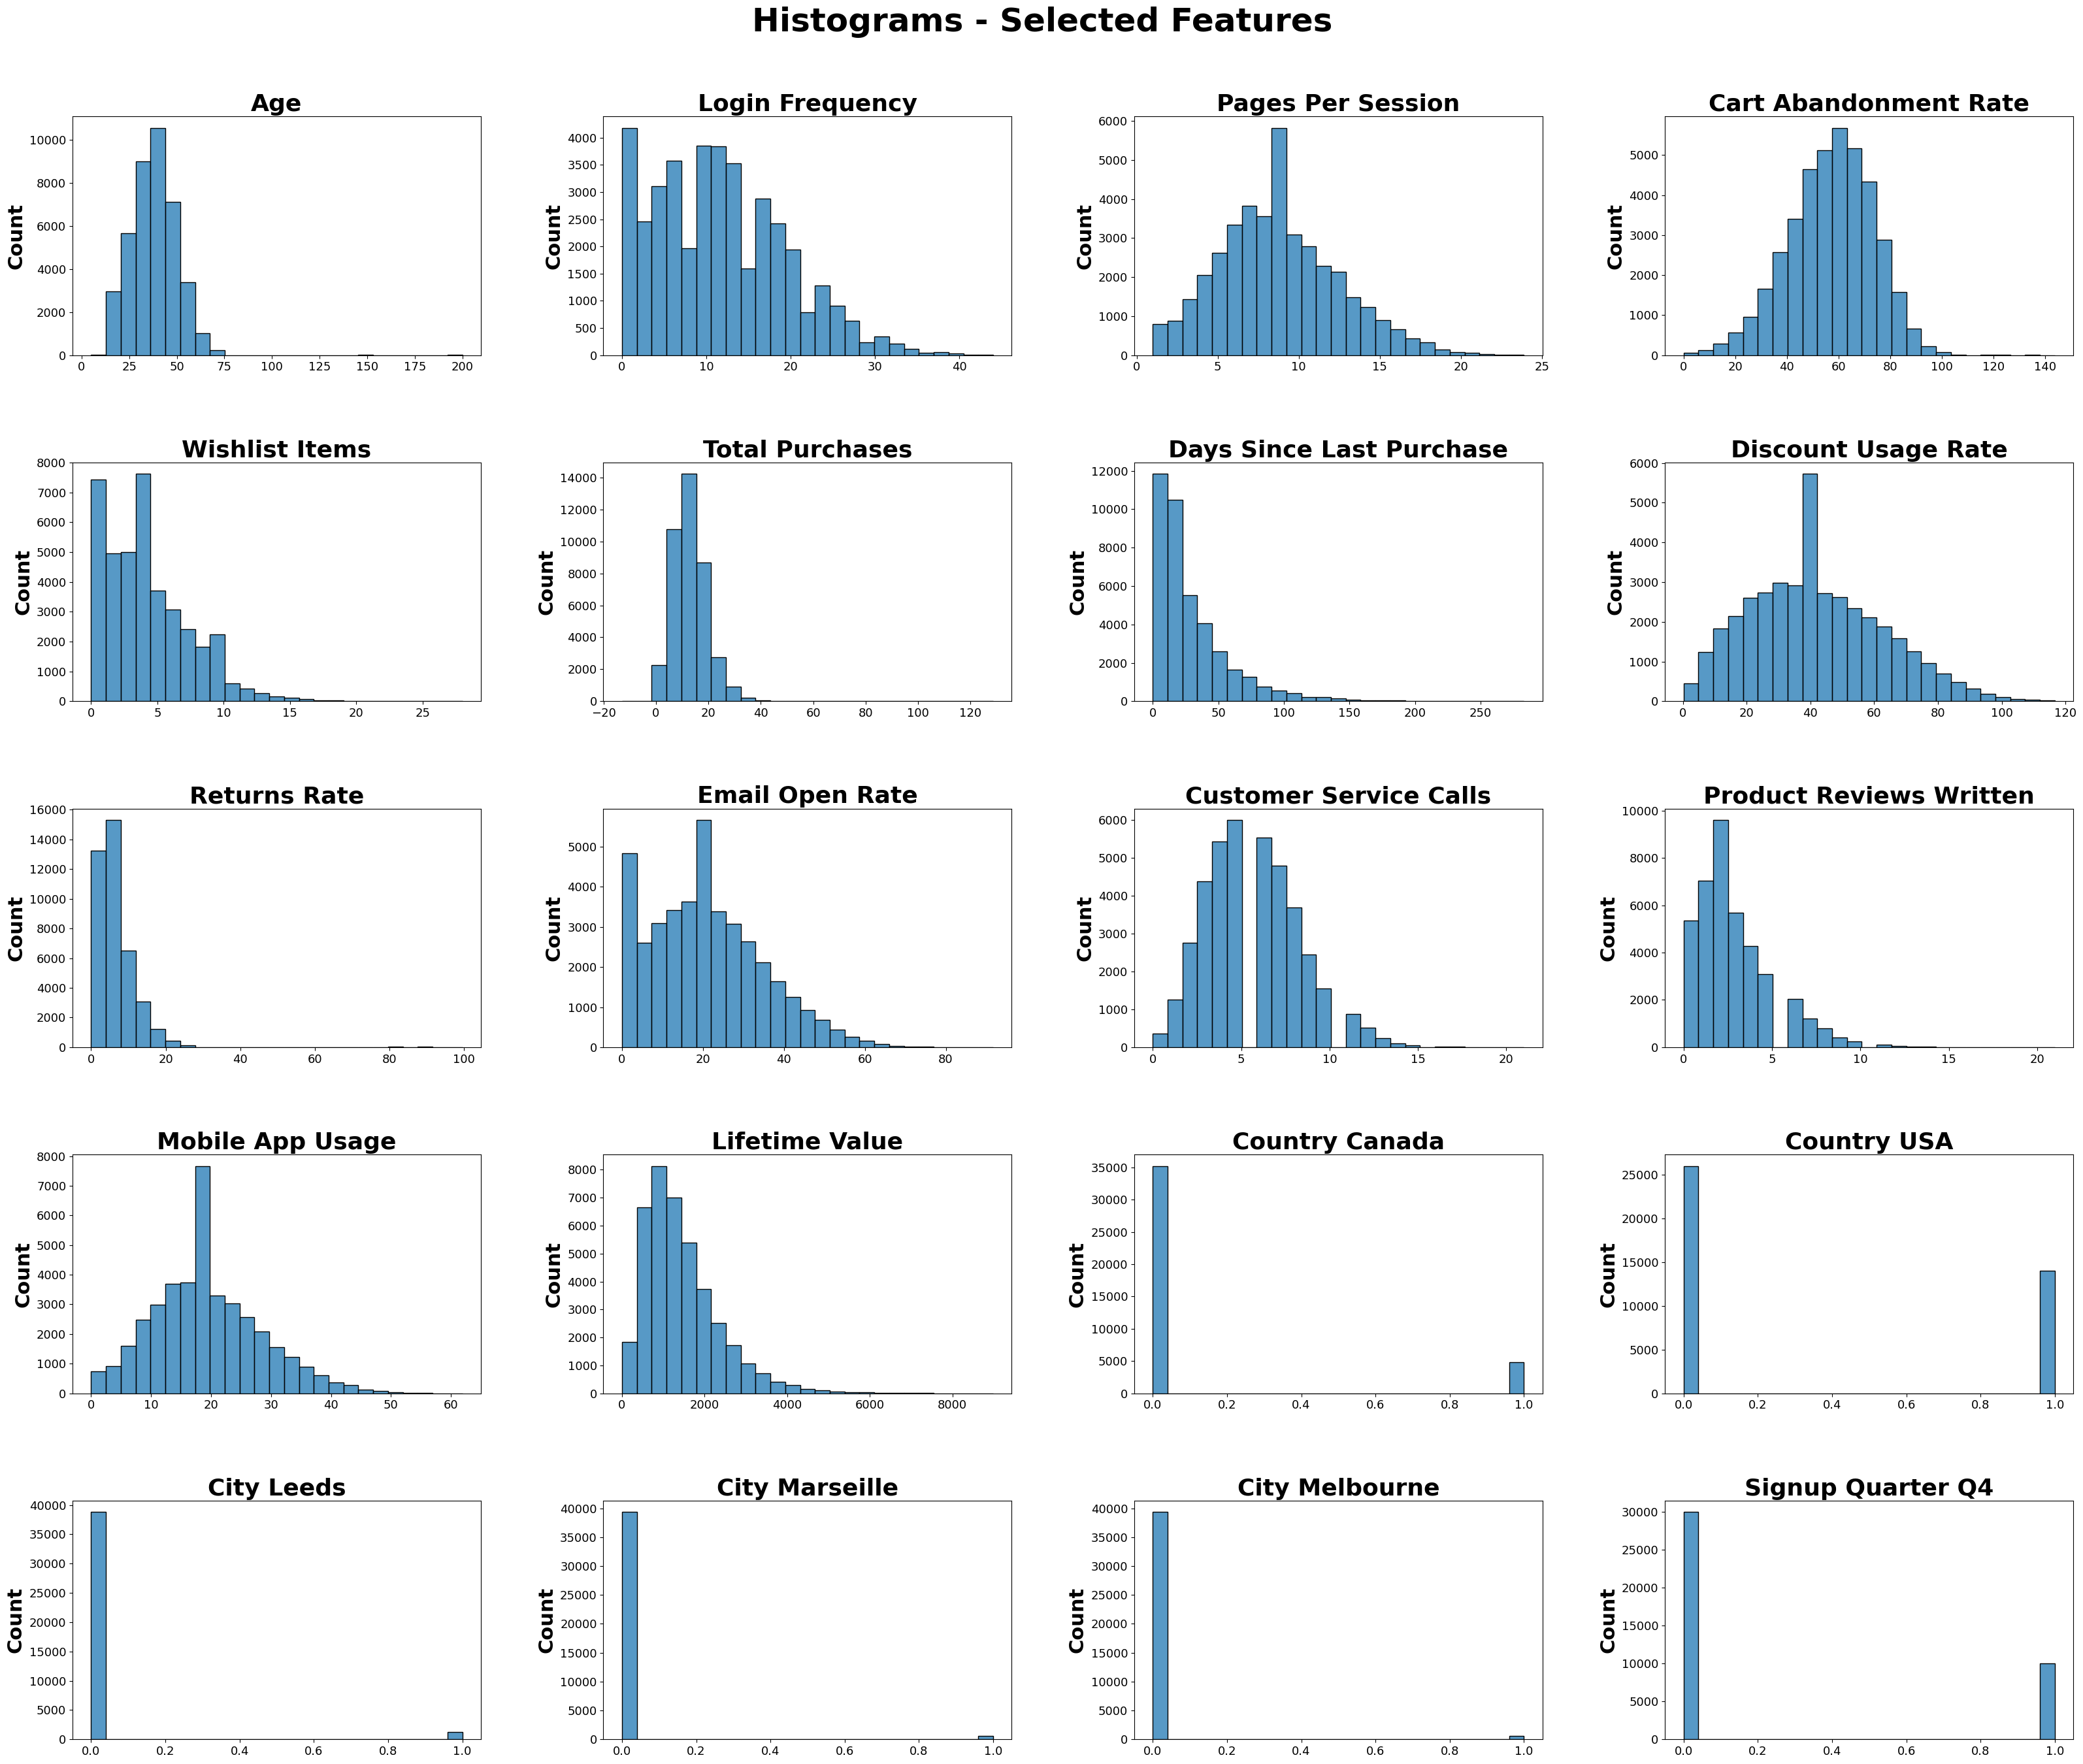

In [23]:
plot_histograms(df_eda, selected_features)

In [24]:
def plot_features_vs_target(df_eda, feature_list, target_col="Churned", n_cols=4):
    n = len(feature_list)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(8 * n_cols, 5.8 * n_rows))
    plt.suptitle("Selected Features vs Churn", fontsize=36, weight="bold")

    for i, col in enumerate(feature_list, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        unique_vals = sorted(df_eda[col].dropna().unique())

        # low-cardinality feature -> churn rate barplot
        if len(unique_vals) <= 4:
            temp = df_eda.groupby(col)[target_col].mean().reset_index()
            sns.barplot(data=temp, x=col, y=target_col, ax=ax)

            ax.set_ylabel("Churn Rate", fontsize=18, weight="bold")
            ax.set_xlabel(get_feature_label(col), fontsize=22, weight="bold")

        # continuous feature -> boxplot
        else:
            sns.boxplot(data=df_eda, x=target_col, y=col, ax=ax)

            ax.set_ylabel(get_feature_label(col), fontsize=18, weight="bold")
            ax.set_xlabel("Churned", fontsize=22, weight="bold")

        ax.set_title(get_feature_label(col), fontsize=26, weight="bold")
        ax.tick_params(axis="both", labelsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.55, wspace=0.35)
    plt.savefig("figure2_features_vs_churn.png", dpi=300, bbox_inches="tight")

    plt.show()

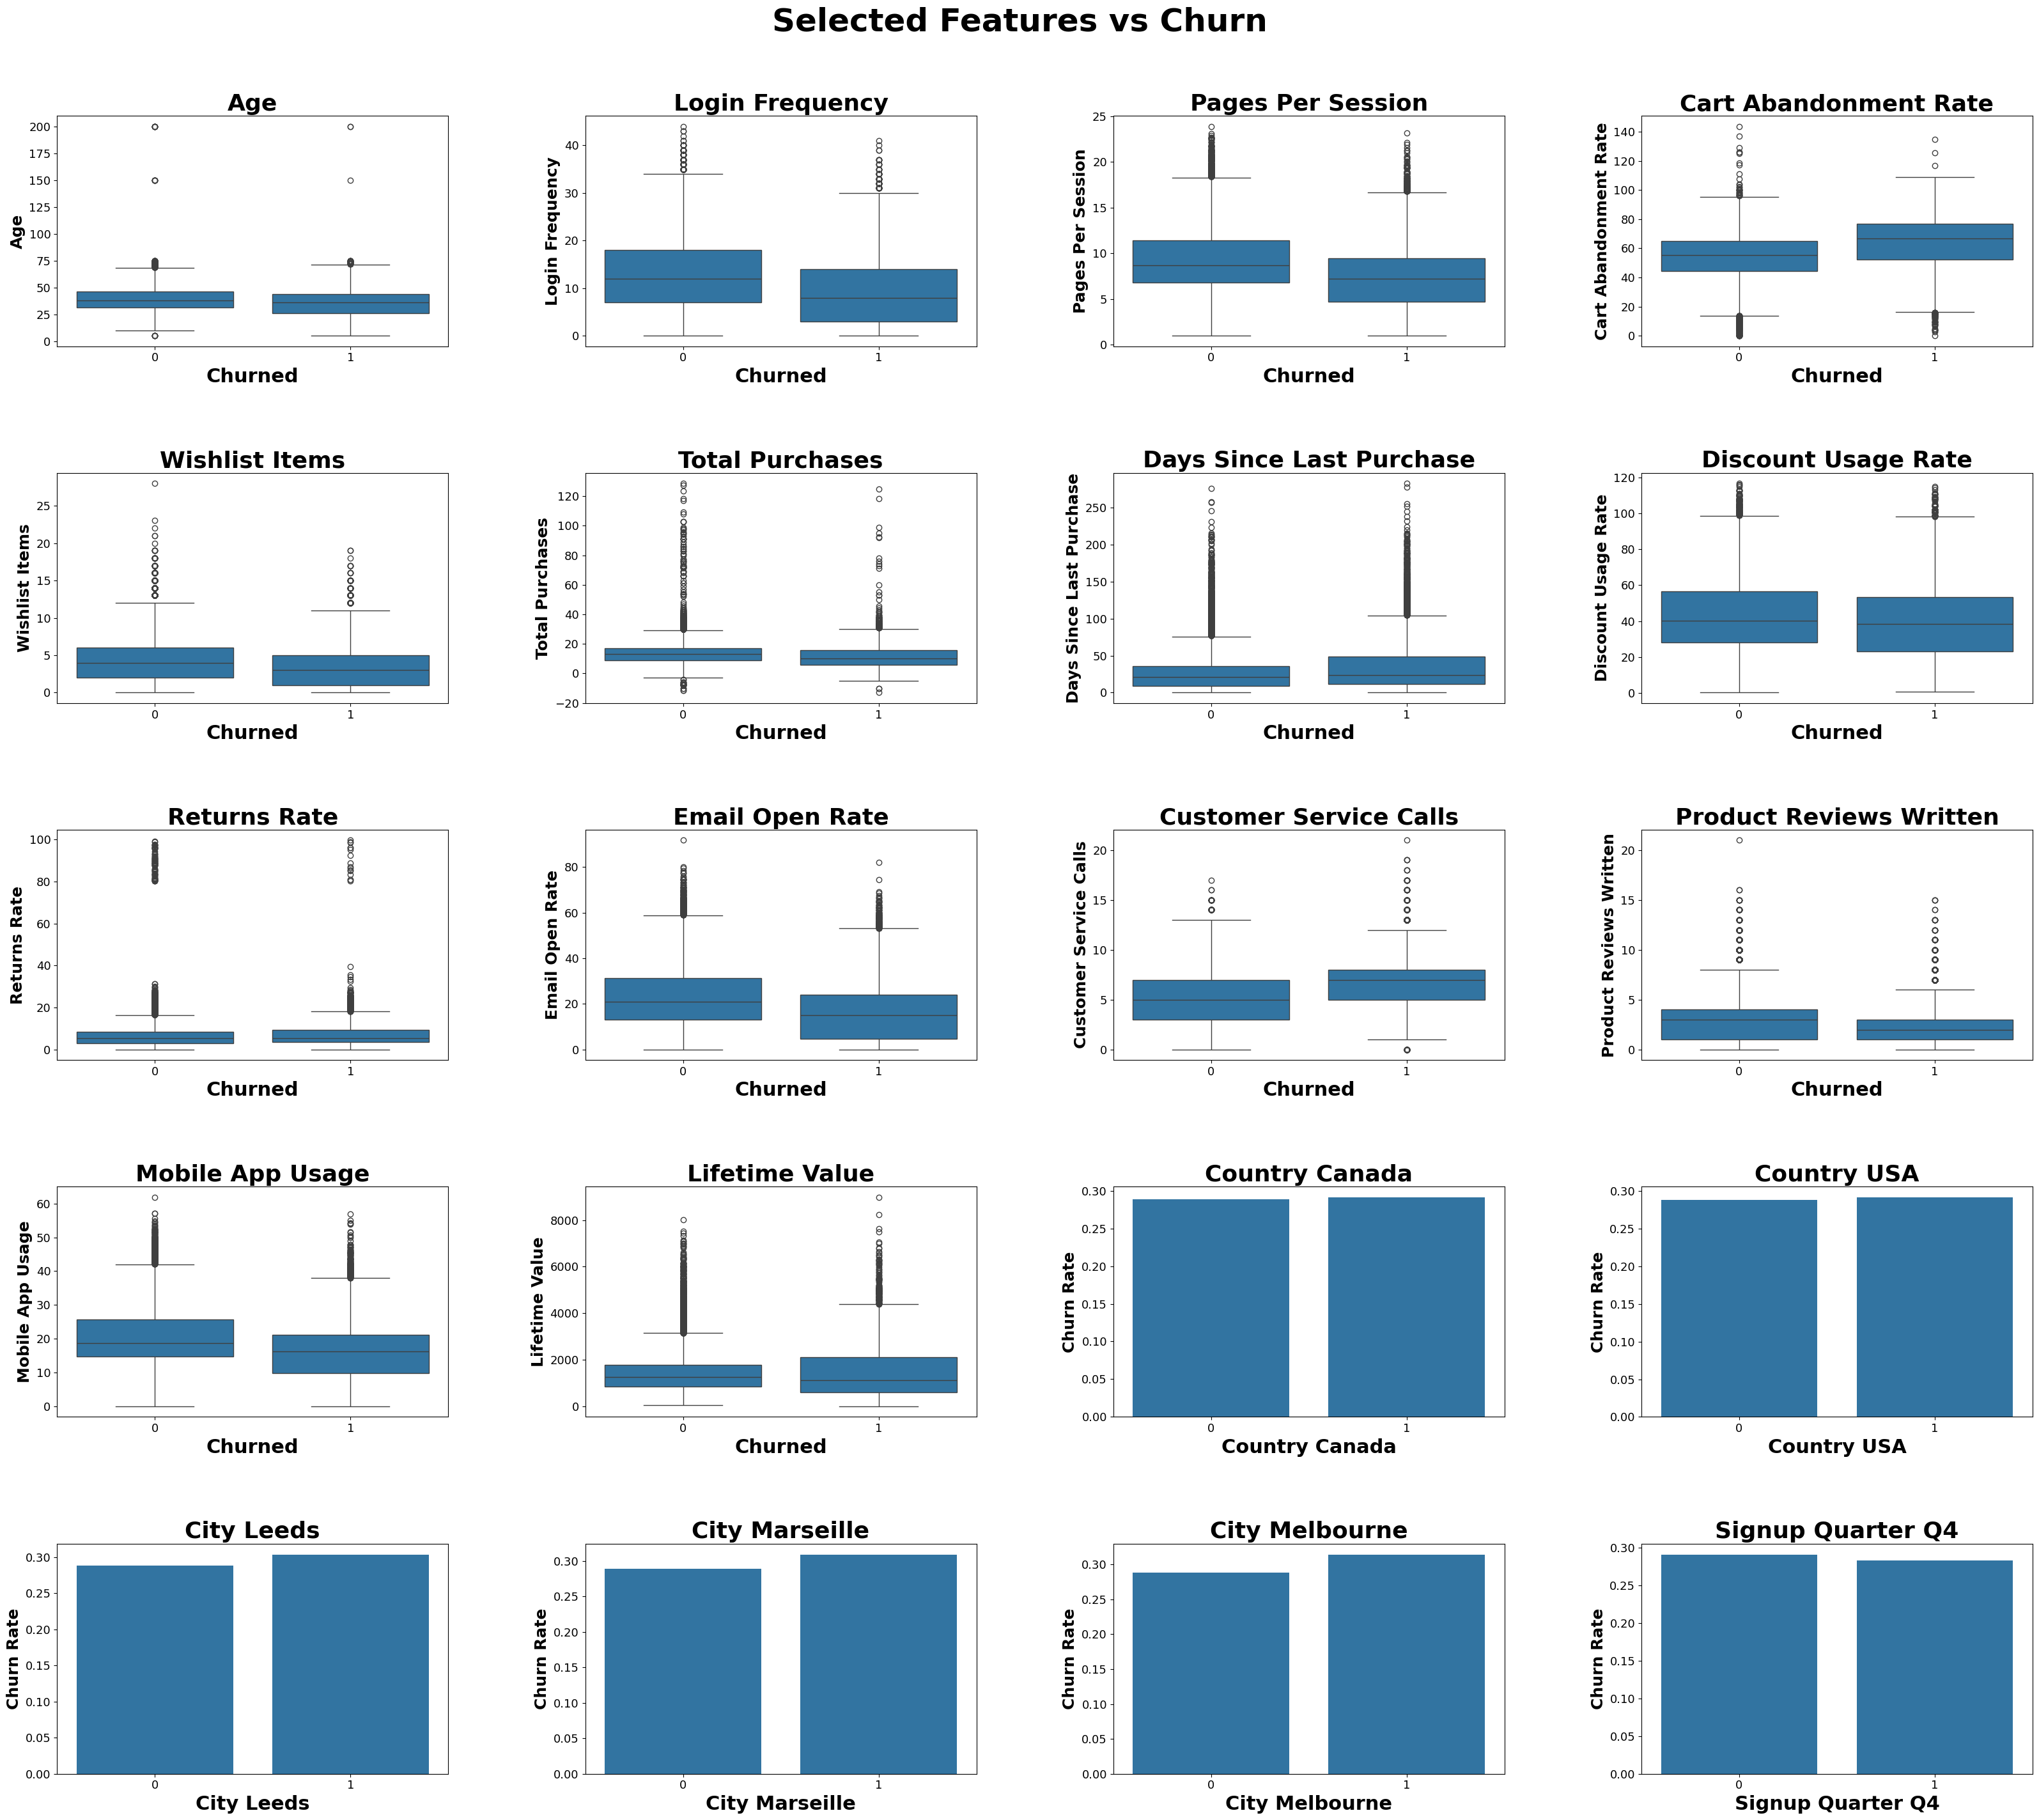

In [25]:
plot_features_vs_target(df_eda, selected_features, target_col="Churned")

In [26]:
def plot_sorted_corr_heatmap(df_eda, feature_list, target_col="Churned"):
    corr = df_eda[feature_list + [target_col]].corr(numeric_only=True)
    sorted_features = corr[target_col].sort_values(ascending=True).index.tolist()
    corr_single = corr.loc[sorted_features, [target_col]]

    plt.figure(figsize=(6, 8))
    ax = sns.heatmap(
        corr_single,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 10},
        cbar_kws={"shrink": 0.8}
    )

    y_labels = [
        get_feature_label(f) if f != target_col else "Target (Churned)"
        for f in sorted_features
    ]
    ax.set_yticklabels(y_labels, rotation=0, fontsize=12, weight="bold")
    ax.set_xticklabels(["Churned"], fontsize=12, weight="bold")

    plt.title("Correlation Heatmap (Sorted) - Selected Features", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig("figure3_correlation_heatmap.png", dpi=300, bbox_inches="tight")

    plt.show()

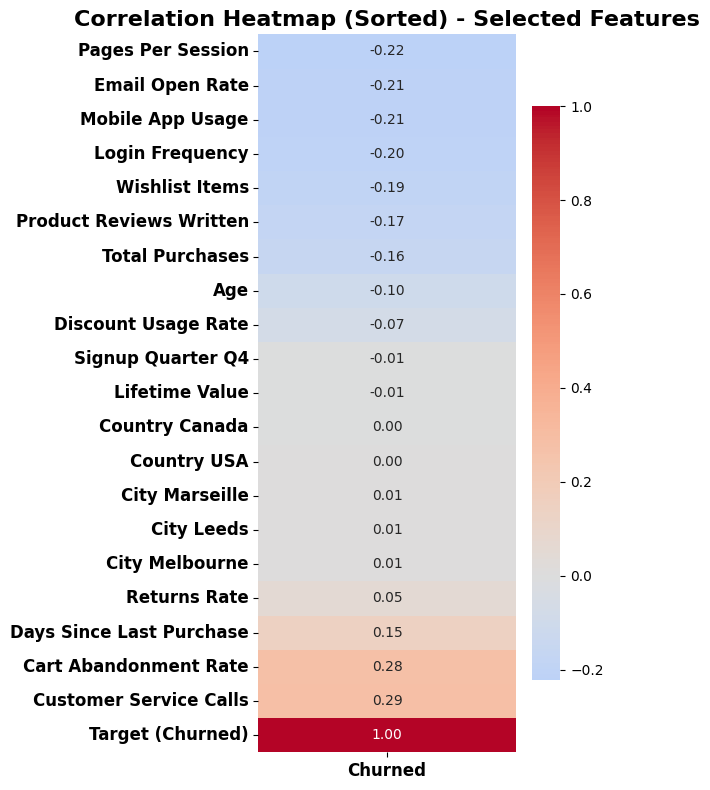

In [27]:
plot_sorted_corr_heatmap(df_eda, selected_features, target_col="Churned")

In [28]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test_use, y_test, model_name="Model"):
    y_prob = model.predict_proba(X_test_use)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 5))
    plt.plot(
        fpr, tpr,
        label=f"{model_name} (AUC = {roc_auc:.3f})",
        linewidth=2
    )
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate", fontsize=12, weight="bold")
    plt.ylabel("True Positive Rate", fontsize=12, weight="bold")
    plt.title(f"ROC Curve - Final Best Model - {model_name}", fontsize=16, weight="bold")
    plt.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("figure4_roc_curve.png", dpi=300, bbox_inches="tight")

    plt.show()

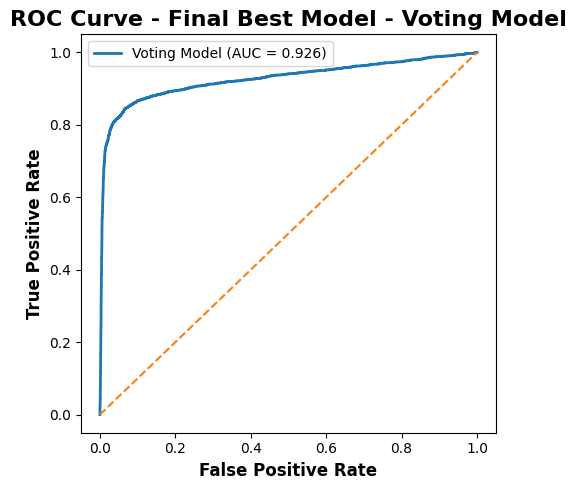

In [29]:
plot_roc_curve(vote_model, X_test_scaled, y_test, model_name="Voting Model")